In [101]:
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [102]:
from collections import defaultdict
import graphviz

In [103]:
def mk_node_data(path):
    node_info = {}
    edges = defaultdict(list)
    mode = None
    with open(path) as f:
        for line in f.readlines():
            # Section header
            if len(line.split(":")) > 1:
                section_type = line.split(":")[1].strip()
                mode = section_type
                #print(section_type)
                continue
            if mode == "node_info":
                # node_id, n_visits, exploitation, h-value
                vals = line.split(",")
                assert len(vals) == 4
                node_id = int(vals[0])
                n_visits = int(vals[1])
                exploitation = float(vals[2])
                h_value = float(vals[3])
                node_info[node_id] = (n_visits, exploitation, h_value)
            elif mode == "node_edges":
                # node_id_parent, node_id_child
                vals = line.split(",")
                assert len(vals) == 2
                parent_id = int(vals[0])
                child_id = int(vals[1])
                edges[parent_id].append(child_id)
            else:
                assert False, "Invalid mode!"
    return node_info, edges

In [113]:
node_info, node_edges = mk_node_data("../output/tree_dag.csv")

In [114]:
len(node_edges)

197484

In [106]:
def node_sizes(node_info, index):
    max_v = max([v[index] for v in node_info.values()])
    node_sizes = { n : v[index] / max_v for n, v in node_info.items() }
    return node_sizes

In [107]:
n_visit_sizes = node_sizes(node_info, 0)
exploitation_sizes = node_sizes(node_info, 1)
heuristic_sizes = node_sizes(node_info, 2)

In [108]:
def mk_graph(node_info, node_edges, sizes):
    graph = graphviz.Graph()
    for i in node_info.keys():
        graph.node(str(i), "", **{"width": str(sizes[i]), "height": str(sizes[i])})
    for parent, children in node_edges.items():
        for child in children:
            graph.edge(str(parent), str(child))
    return graph

In [109]:
#graph = mk_graph(node_info, node_edges, n_visit_sizes)
graph = mk_graph(node_info, node_edges, exploitation_sizes)
#graph = mk_graph(node_info, node_edges, heuristic_sizes)

In [110]:
graph.render("tree_dag")

'tree_dag.pdf'

In [111]:
# Correlation of visit count to heuristic value (won't work; the root has a low value but a lot of visits
# Depth * Visit count -> Value?
# Correlation of estimated value to heuristic value

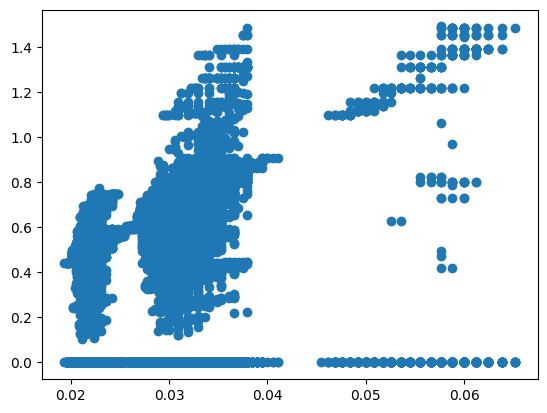

In [117]:
# estimated value
ys = [node_info[k][1] for k in node_info]
# "true" value - h-score
xs = [node_info[k][2] for k in node_info]
xs, ys = zip(*[(x,y) for (x,y) in zip(xs, ys) if x !=0])
scatter(xs, ys)